In [ ]:
# ============================================================
# GRAPH-BASED SPATIO-TEMPORAL BEHAVIORAL PHENOTYPING
# FOR PERSONALIZED ANXIETY VULNERABILITY MAPPING
# ============================================================
# StudentLife Dataset — Clean Combined Pipeline


# ── CELL 1: Install & Imports ────────────────────────────────
# ============================================================

!pip install torch-geometric pyreadr haversine umap-learn -q

from google.colab import drive
drive.mount('/content/drive')

import os, json, warnings, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from collections import defaultdict
from datetime import datetime
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, mean_absolute_error, silhouette_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from haversine import haversine, Unit
import umap

import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, GlobalAttention, global_mean_pool, global_max_pool

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
matplotlib.rcParams['figure.dpi'] = 120

print(f"PyTorch     : {torch.__version__}")
print(f"PyG         : {torch_geometric.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {device}")


# ── CELL 2: Configuration ────────────────────────────────────
# ============================================================
# !! EDIT THESE PATHS TO MATCH YOUR GOOGLE DRIVE LAYOUT !!

DATASET_PATH = "/content/drive/MyDrive/Anxiety/dataset/archive (1)/dataset/"
OUTPUT_DIR   = "/content/drive/MyDrive/Anxiety/outputs/"
MODELS_DIR   = "/content/drive/MyDrive/Anxiety/models/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Time windows used for feature bucketing
TIME_WINDOWS = {
    'morning'  : (6,  12),
    'afternoon': (12, 18),
    'evening'  : (18, 23),
    'night'    : (23, 30),   # 23–06 wraps
}
WINDOW_ORDER = ['morning', 'afternoon', 'evening', 'night']

# PHQ-9 scoring
PHQ_MAP = {
    'Not at all': 0,
    'Several days': 1,
    'More than half the days': 2,
    'Nearly every day': 3,
    'nan': 0,
}
SCORE_COLS = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9']

# Verify dataset exists
assert os.path.exists(DATASET_PATH), f"Dataset not found at {DATASET_PATH}"
n_gps    = len(os.listdir(DATASET_PATH + "sensing/gps/"))
n_stress = len(os.listdir(DATASET_PATH + "EMA/response/Stress/"))
print(f"GPS files    : {n_gps}")
print(f"Stress files : {n_stress}")
print("Configuration OK")


# ── CELL 3: Data Loading ─────────────────────────────────────
# ============================================================

def get_users():
    files = os.listdir(DATASET_PATH + "sensing/gps/")
    return sorted([
        f.replace("gps_","").replace(".csv","")
        for f in files if f.startswith("gps_") and f.endswith(".csv")
    ])

def load_gps(uid):
    path = DATASET_PATH + f"sensing/gps/gps_{uid}.csv"
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path, header=0, index_col=False)
        df.columns = df.columns.str.strip().str.lower()
        if len(df) < 10 or 'time' not in df.columns:
            return None
        df['user_id']    = uid
        df['timestamp']  = pd.to_datetime(df['time'], unit='s', errors='coerce')
        df = df.dropna(subset=['timestamp','latitude','longitude'])
        df['hour']       = df['timestamp'].dt.hour
        df['date']       = df['timestamp'].dt.date
        df['day_of_week']= df['timestamp'].dt.dayofweek
        return df
    except:
        return None

def load_activity(uid):
    path = DATASET_PATH + f"sensing/activity/activity_{uid}.csv"
    if not os.path.exists(path):
        return None
    try:
        with open(path,'r') as f:
            first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr:
            df.columns = ['timestamp','activity_inference']
        else:
            df.columns = df.columns.str.strip().str.lower()
            rename = {}
            for c in df.columns:
                if 'time'  in c: rename[c] = 'timestamp'
                if 'activ' in c: rename[c] = 'activity_inference'
            df = df.rename(columns=rename)
        if len(df) < 10:
            return None
        df['user_id']   = uid
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
        df = df.dropna(subset=['timestamp'])
        act_map = {0:'STATIONARY',1:'WALKING',2:'RUNNING',3:'UNKNOWN'}
        df['activity'] = df['activity_inference'].map(act_map).fillna('UNKNOWN')
        return df
    except:
        return None

def load_stress(uid):
    path = DATASET_PATH + f"EMA/response/Stress/Stress_{uid}.json"
    if not os.path.exists(path):
        return None
    try:
        with open(path) as f:
            data = json.load(f)
        if not data or len(data) < 3:
            return None
        records = []
        for entry in data:
            ts    = pd.to_datetime(entry.get('resp_time',0), unit='s')
            level = entry.get('level', None)
            if level is None:
                continue
            records.append({
                'user_id'     : uid,
                'timestamp'   : ts,
                'stress_level': float(level),
                'hour'        : ts.hour,
                'date'        : ts.date()
            })
        return pd.DataFrame(records) if len(records) >= 3 else None
    except:
        return None

def load_conversation(uid):
    path = DATASET_PATH + f"sensing/conversation/conversation_{uid}.csv"
    if not os.path.exists(path):
        return None
    try:
        with open(path,'r') as f:
            first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr:
            df.columns = ['start_time','end_time','inference']
        else:
            df.columns = df.columns.str.strip().str.lower()
        df['user_id']      = uid
        col0               = df.columns[0]
        col1               = df.columns[1]
        df['start_time']   = pd.to_datetime(df[col0], unit='s', errors='coerce')
        df['end_time']     = pd.to_datetime(df[col1], unit='s', errors='coerce')
        df['duration_min'] = (df['end_time'] - df['start_time']).dt.seconds / 60
        df['hour']         = df['start_time'].dt.hour
        return df.dropna(subset=['start_time'])
    except:
        return None

def load_phonelock(uid):
    path = DATASET_PATH + f"sensing/phonelock/phonelock_{uid}.csv"
    if not os.path.exists(path):
        return None
    try:
        with open(path,'r') as f:
            first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr:
            df.columns = ['start_timestamp','end_timestamp','lock']
        else:
            df.columns = df.columns.str.strip().str.lower()
        df['user_id']    = uid
        df['start_time'] = pd.to_datetime(df[df.columns[0]], unit='s', errors='coerce')
        df['hour']       = df['start_time'].dt.hour
        return df.dropna(subset=['start_time'])
    except:
        return None

def load_phq9():
    path = DATASET_PATH + "survey/PHQ-9.csv"
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip().str.lower()
        return df
    except:
        return None

# ── Load all users ───────────────────────────────────────────
USERS = get_users()
print(f"Users found : {len(USERS)}\n")

all_gps, all_activity, all_stress = {}, {}, {}
all_conversation, all_phonelock   = {}, {}

for uid in USERS:
    g = load_gps(uid)
    a = load_activity(uid)
    s = load_stress(uid)
    c = load_conversation(uid)
    p = load_phonelock(uid)
    if g is not None: all_gps[uid]          = g
    if a is not None: all_activity[uid]     = a
    if s is not None: all_stress[uid]       = s
    if c is not None: all_conversation[uid] = c
    if p is not None: all_phonelock[uid]    = p

valid_users = sorted(set(all_gps) & set(all_activity) & set(all_stress))
print(f"GPS loaded          : {len(all_gps)}")
print(f"Activity loaded     : {len(all_activity)}")
print(f"Stress loaded       : {len(all_stress)}")
print(f"Conversation loaded : {len(all_conversation)}")
print(f"Phone lock loaded   : {len(all_phonelock)}")
print(f"Valid users         : {len(valid_users)}")


# ── CELL 4: GPS Cleaning & Stay-Point Detection ──────────────
# ============================================================

def clean_gps(df):
    df = df.copy()
    df = df[df['latitude'].between(-90, 90)]
    df = df[df['longitude'].between(-180, 180)]
    df = df[df['accuracy'] < 100]
    df = df.dropna(subset=['latitude','longitude'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    speeds = [0.0]
    for i in range(1, len(df)):
        try:
            dist = haversine(
                (df.loc[i-1,'latitude'], df.loc[i-1,'longitude']),
                (df.loc[i,  'latitude'], df.loc[i,  'longitude']),
                unit=Unit.METERS
            )
            dt = max((df.loc[i,'timestamp'] - df.loc[i-1,'timestamp']).seconds, 1)
            speeds.append(dist / dt)
        except:
            speeds.append(0.0)
    df['speed_mps'] = speeds
    return df[df['speed_mps'] < 55].reset_index(drop=True)

def detect_stay_points(gps_df):
    coords = gps_df[['latitude','longitude']].values
    eps_rad = 50 / 6_371_000          # 50 m in radians
    labels  = DBSCAN(
        eps=eps_rad, min_samples=5,
        algorithm='ball_tree', metric='haversine'
    ).fit(np.radians(coords)).labels_
    gps_df = gps_df.copy()
    gps_df['location_cluster'] = labels
    centers = {}
    for cid in set(labels):
        if cid == -1:
            continue
        mask = labels == cid
        centers[cid] = {
            'lat'        : coords[mask, 0].mean(),
            'lon'        : coords[mask, 1].mean(),
            'visit_count': int(mask.sum())
        }
    return gps_df, centers

print("Cleaning GPS & detecting stay points...")
all_gps_clean    = {}
all_gps_clustered = {}
all_cluster_centers = {}

for uid in valid_users:
    cleaned = clean_gps(all_gps[uid])
    if len(cleaned) < 100:
        continue
    clustered, centers = detect_stay_points(cleaned)
    all_gps_clean[uid]       = cleaned
    all_gps_clustered[uid]   = clustered
    all_cluster_centers[uid] = centers

valid_users = sorted(set(all_gps_clustered) & set(all_activity) & set(all_stress))
print(f"After GPS cleaning : {len(valid_users)} valid users")


# ── CELL 5: Build Contextual States ─────────────────────────
# ============================================================

def get_time_category(hour):
    if   0  <= hour < 6:  return 'NIGHT'
    elif 6  <= hour < 12: return 'MORNING'
    elif 12 <= hour < 17: return 'AFTERNOON'
    elif 17 <= hour < 21: return 'EVENING'
    else:                 return 'LATE_NIGHT'

def build_contextual_states(uid):
    gps = all_gps_clustered[uid].copy()
    act = all_activity[uid]
    st  = all_stress[uid]

    gps['time_category'] = gps['hour'].apply(get_time_category)

    # Merge nearest activity reading (within 5 min)
    gps = pd.merge_asof(
        gps.sort_values('timestamp'),
        act[['timestamp','activity']].sort_values('timestamp'),
        on='timestamp', tolerance=pd.Timedelta('5min'),
        direction='nearest'
    )
    gps['activity'] = gps['activity'].fillna('UNKNOWN')

    # Merge nearest stress reading (within 3 hours)
    gps = pd.merge_asof(
        gps.sort_values('timestamp'),
        st[['timestamp','stress_level']].sort_values('timestamp'),
        on='timestamp', tolerance=pd.Timedelta('3hours'),
        direction='nearest'
    )

    gps['contextual_state'] = (
        'LOC_' + gps['location_cluster'].astype(str) +
        '__'   + gps['time_category'] +
        '__'   + gps['activity']
    )
    return gps

print("Building contextual states...")
user_ctx = {}
for uid in valid_users:
    try:
        ctx = build_contextual_states(uid)
        user_ctx[uid] = ctx
    except Exception as e:
        print(f"  {uid} failed: {e}")

print(f"Contextual states built for {len(user_ctx)} users")


# ── CELL 6: Build Behavioral Graphs ─────────────────────────
# ============================================================

def build_behavioral_graph(uid):
    df = user_ctx[uid].copy()
    df = df[df['location_cluster'] != -1]       # drop transit points
    df = df.dropna(subset=['contextual_state'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    if len(df) < 10:
        return None

    G = nx.DiGraph()
    G.graph['user_id'] = uid

    states      = df['contextual_state'].tolist()
    stress_vals = df['stress_level'].tolist() if 'stress_level' in df.columns else [None]*len(df)
    hours       = df['hour'].tolist()
    days        = df['day_of_week'].tolist()

    node_stats = defaultdict(lambda: {
        'visits': 0, 'stress': [], 'hours': [], 'weekday': 0, 'weekend': 0
    })

    for i, state in enumerate(states):
        ns = node_stats[state]
        ns['visits'] += 1
        ns['hours'].append(hours[i])
        if days[i] < 5: ns['weekday'] += 1
        else:           ns['weekend'] += 1
        v = stress_vals[i]
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            ns['stress'].append(float(v))

    for state, ns in node_stats.items():
        sr = ns['stress']
        G.add_node(state,
            visit_count       = ns['visits'],
            typical_hour      = float(np.mean(ns['hours'])),
            hour_std          = float(np.std(ns['hours'])),
            weekday_ratio     = ns['weekday'] / max(ns['visits'], 1),
            mean_stress       = float(np.mean(sr)) if sr else 0.0,
            max_stress        = float(np.max(sr))  if sr else 0.0,
            std_stress        = float(np.std(sr))  if sr else 0.0,
            high_stress_ratio = sum(1 for s in sr if s >= 3) / max(len(sr), 1),
            n_stress_obs      = len(sr),
            stress_readings   = sr,
        )

    for i in range(len(states) - 1):
        src, dst = states[i], states[i+1]
        gap_min  = (df['timestamp'].iloc[i+1] - df['timestamp'].iloc[i]).seconds / 60
        if gap_min > 240:
            continue
        if G.has_edge(src, dst):
            G[src][dst]['weight'] += 1
        else:
            G.add_edge(src, dst, weight=1, avg_gap=gap_min)

    return G if G.number_of_nodes() >= 3 and G.number_of_edges() >= 2 else None

print("Building behavioral graphs...")
user_graphs = {}
for uid in valid_users:
    G = build_behavioral_graph(uid)
    if G is not None:
        user_graphs[uid] = G

print(f"Graphs built : {len(user_graphs)} users")
print(f"\n{'User':<6} {'Nodes':>6} {'Edges':>6} {'Stress obs':>11}")
print("-"*32)
for uid, G in sorted(user_graphs.items()):
    n_s = sum(len(G.nodes[n]['stress_readings']) for n in G.nodes)
    print(f"{uid:<6} {G.number_of_nodes():>6} {G.number_of_edges():>6} {n_s:>11}")


# ── CELL 7: Labels — Stress EMA only ────────────────────────
# ============================================================
# Your dataset uses RDS format for PHQ-9 which requires pyreadr.
# We use stress EMA labels directly — fully valid for your research.

label_map  = {}
label_type = 'regression'

for uid, G in user_graphs.items():
    all_sr = [s for n in G.nodes for s in G.nodes[n]['stress_readings']]
    if all_sr:
        label_map[uid] = float(np.mean([1 if s >= 3 else 0 for s in all_sr]))

print(f"Label type      : {label_type}")
print(f"Users labelled  : {len(label_map)}")

scores = list(label_map.values())
print(f"Score range     : {min(scores):.3f} – {max(scores):.3f}")
print(f"Mean score      : {np.mean(scores):.3f}")
print(f"High vuln (≥0.5): {sum(1 for s in scores if s >= 0.5)}")
print(f"Low  vuln (<0.5): {sum(1 for s in scores if s < 0.5)}")

# ── CELL 8: High-Risk Window Detection ──────────────────────
# ============================================================

def compute_hourly_risk_profile(G, threshold=3.0):
    hourly = defaultdict(list)
    for node, attrs in G.nodes(data=True):
        h = int(round(attrs.get('typical_hour', 12))) % 24
        for s in attrs.get('stress_readings', []):
            hourly[h].append(s)
    profile = {}
    for h in range(24):
        readings = hourly.get(h, [])
        profile[h] = {
            'mean_stress'     : np.mean(readings) if readings else 0.0,
            'risk_probability': np.mean([1 if s >= threshold else 0 for s in readings])
                                if readings else 0.0,
            'n_observations'  : len(readings),
        }
    return profile

def detect_top_risk_windows(profile, top_k=2, window_hrs=2):
    risk = np.array([profile[h]['risk_probability'] for h in range(24)])
    windows = []
    for start in range(24):
        hrs   = [(start + i) % 24 for i in range(window_hrs)]
        score = float(np.mean(risk[hrs]))
        obs   = sum(profile[h]['n_observations'] for h in hrs)
        windows.append({'start': start, 'end': (start+window_hrs)%24,
                        'score': score, 'obs': obs})
    windows.sort(key=lambda x: x['score'], reverse=True)
    selected, used = [], set()
    for w in windows:
        if w['obs'] < 2:
            continue
        if not any(h in used for h in [(w['start']+i)%24 for i in range(window_hrs)]):
            selected.append(w)
            used.update([(w['start']+i)%24 for i in range(window_hrs)])
        if len(selected) == top_k:
            break
    return selected

def risk_level(score):
    if score >= 0.7: return 'CRITICAL'
    if score >= 0.5: return 'HIGH'
    if score >= 0.3: return 'MODERATE'
    return 'LOW'

print("Computing risk profiles...")
all_profiles = {}
all_windows  = {}
for uid, G in user_graphs.items():
    p = compute_hourly_risk_profile(G)
    w = detect_top_risk_windows(p)
    all_profiles[uid] = p
    all_windows[uid]  = w

print(f"Risk profiles computed for {len(all_profiles)} users\n")
print(f"{'User':<6} {'Window 1':<18} {'Score':>6}  {'Level':<10} {'Window 2':<18} {'Score':>6}")
print("-"*72)
for uid in sorted(all_windows):
    ws = all_windows[uid]
    def fmt(w):
        return f"{w['start']:02d}:00–{w['end']:02d}:00", f"{w['score']:.2f}", risk_level(w['score'])
    if len(ws) >= 2:
        t1,s1,l1 = fmt(ws[0]); t2,s2,l2 = fmt(ws[1])
        print(f"{uid:<6} {t1:<18} {s1:>6}  {l1:<10} {t2:<18} {s2:>6}")
    elif len(ws) == 1:
        t1,s1,l1 = fmt(ws[0])
        print(f"{uid:<6} {t1:<18} {s1:>6}  {l1:<10} {'—':<18}")




# ── CELL 9: Convert Graphs to PyTorch Geometric ──────────────
# ============================================================

def get_social_features(uid, typical_hour):
    """Conversation duration and phone unlock count for a given hour."""
    h = int(round(typical_hour)) % 24

    conv_norm = 0.0
    if uid in all_conversation:
        conv_df = all_conversation[uid]
        hour_conv = conv_df[conv_df['hour'] == h]['duration_min'].sum()
        total_conv = conv_df['duration_min'].sum()
        conv_norm = min(hour_conv / max(total_conv, 1), 1.0)

    lock_norm = 0.0
    if uid in all_phonelock:
        lock_df  = all_phonelock[uid]
        hour_lock  = len(lock_df[lock_df['hour'] == h])
        total_lock = len(lock_df)
        lock_norm  = min(hour_lock / max(total_lock, 1) * 10, 1.0)

    return conv_norm, lock_norm

def graph_to_pyg(G, uid, profile, label):
    nodes = list(G.nodes())
    if len(nodes) < 2:
        return None
    n2i = {n: i for i, n in enumerate(nodes)}

    # 9 node features (7 original + 2 social)
    rows = []
    for n in nodes:
        conv_n, lock_n = get_social_features(
            uid, G.nodes[n]['typical_hour']
        )
        rows.append([
            G.nodes[n]['visit_count']       / 100.0,
            G.nodes[n]['typical_hour']      / 24.0,
            G.nodes[n]['hour_std']          / 12.0,
            G.nodes[n]['weekday_ratio'],
            G.nodes[n]['mean_stress']       / 4.0,
            G.nodes[n]['high_stress_ratio'],
            G.nodes[n]['std_stress']        / 3.0,
            conv_n,   # conversation duration ratio
            lock_n,   # phone unlock frequency ratio
        ])
    x = torch.tensor(rows, dtype=torch.float)

    edges = list(G.edges(data=True))
    if not edges:
        return None

    edge_index = torch.tensor(
        [[n2i[e[0]], n2i[e[1]]] for e in edges],
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        [[e[2].get('weight',1) / 10.0,
          e[2].get('avg_gap',30) / 240.0]
         for e in edges],
        dtype=torch.float
    )

    y           = torch.tensor([label], dtype=torch.float)
    hourly_risk = torch.tensor(
        [profile[h]['risk_probability'] for h in range(24)],
        dtype=torch.float
    )

    return Data(
        x=x, edge_index=edge_index, edge_attr=edge_attr,
        y=y, hourly_risk=hourly_risk,
        num_nodes=len(nodes), user_id=uid
    )

dataset  = []
skipped  = []
uid_list = []

for uid in sorted(user_graphs):
    if uid not in label_map or uid not in all_profiles:
        skipped.append(uid); continue
    d = graph_to_pyg(user_graphs[uid], uid, all_profiles[uid], label_map[uid])
    if d is not None:
        dataset.append(d)
        uid_list.append(uid)
    else:
        skipped.append(uid)

print(f"PyG dataset  : {len(dataset)} graphs")
print(f"Node features: {dataset[0].x.shape[1]} (should be 9)")
print(f"Skipped      : {skipped if skipped else 'none'}")
labels_arr = np.array([d.y.item() for d in dataset])
print(f"\nLabel stats  : min={labels_arr.min():.3f}  max={labels_arr.max():.3f}  mean={labels_arr.mean():.3f}")

binary_all     = (labels_arr >= 0.5).astype(int)
n_high         = binary_all.sum()
n_low          = len(binary_all) - n_high
pos_weight_val = len(binary_all) / (2 * max(n_high, 1))
pos_weight     = torch.tensor([pos_weight_val]).to(device)
print(f"\nClass balance: {n_high} high / {n_low} low  (pos_weight={pos_weight_val:.3f})")

!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
print("SMOTE ready — will be applied inside each training fold")

dataset = [d.cpu() for d in dataset]
print("Dataset moved to CPU — OK")


# ── CELL 10: GATv2 Model ────────────────────────────────────
# ============================================================

class AnxietyGATv2(nn.Module):
    """
    Graph Attention Network v2 for anxiety vulnerability prediction.
    Two output heads:
      - vuln_head : scalar vulnerability score (logit, apply sigmoid)
      - hrw_head  : 24-dim hourly risk probability vector
    """
    def __init__(self, node_feat=9, hidden=64, heads=4, drop=0.3):
        super().__init__()
        self.drop = drop

        self.conv1 = GATv2Conv(node_feat, hidden,
                               heads=heads, dropout=drop,
                               edge_dim=2, concat=True)
        self.conv2 = GATv2Conv(hidden*heads, hidden,
                               heads=1, dropout=drop,
                               edge_dim=2, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden)

        self.vuln_head = nn.Sequential(
            nn.Linear(hidden * 2, 32),
            nn.ELU(),
            nn.Dropout(drop),
            nn.Linear(32, 1)
        )
        self.hrw_head = nn.Sequential(
            nn.Linear(hidden * 2, 48),
            nn.ELU(),
            nn.Dropout(drop),
            nn.Linear(48, 24),
            nn.Sigmoid()
        )

        self._last_attn  = None
        self._last_edges = None

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = self.bn1(F.elu(self.conv1(x, ei, ea)))
        x = F.dropout(x, p=self.drop, training=self.training)
        x, (ei2, attn) = self.conv2(x, ei, ea, return_attention_weights=True)
        x = self.bn2(F.elu(x))
        x = F.dropout(x, p=self.drop, training=self.training)

        self._last_attn  = attn.detach()
        self._last_edges = ei2.detach()

        xg = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=1)

        return self.vuln_head(xg), self.hrw_head(xg)

    def vulnerability_score(self, logit):
        return float(torch.sigmoid(logit).item())

    def high_risk_window(self, hrw_pred=None):
        """
        Use hrw_head prediction directly when available.
        Falls back to attention weights if hrw_pred is None.
        """
        if hrw_pred is not None:
            # Safely flatten — handles (1,24), (24,), or (N,24)
            hrw_np = hrw_pred.detach().cpu().numpy()
            if hrw_np.ndim > 1:
                hrw_np = hrw_np[0]  # take first item, now shape (24,)
            best_score, best_h = -1, 0
            for start in range(24):
                hrs   = [(start + i) % 24 for i in range(2)]
                score = float(np.mean(hrw_np[hrs]))
                if score > best_score:
                    best_score = score
                    best_h     = start
            if   6  <= best_h < 12: return 'morning'
            elif 12 <= best_h < 18: return 'afternoon'
            elif 18 <= best_h < 23: return 'evening'
            else:                   return 'night'

        # Fallback — attention weights
        if self._last_attn is None:
            return 'unknown'
        attn   = self._last_attn.cpu().numpy().flatten()
        src    = self._last_edges[0].cpu().numpy()
        w_attn = np.zeros(4)
        w_cnt  = np.zeros(4)
        for node, a in zip(src, attn):
            h = int(node) % 4
            w_attn[h] += a; w_cnt[h] += 1
        w_avg = w_attn / (w_cnt + 1e-9)
        return WINDOW_ORDER[int(np.argmax(w_avg))]


# Sanity check
_m = AnxietyGATv2().to(device)
_b = Batch.from_data_list([dataset[0].to(device)])
_v, _h = _m(_b)
print(f"Model sanity check OK")
print(f"  Vuln output shape : {_v.shape}")
print(f"  HRW  output shape : {_h.shape}")
del _m, _b, _v, _h


# ── Training Utilities ───────────────────────────────────────

def compute_loss(vuln_logit, hrw_pred, batch, pos_weight):
    vs  = vuln_logit.squeeze(-1)
    y   = batch.y.squeeze(-1)
    bs  = vs.shape[0]
    l_v = F.binary_cross_entropy_with_logits(
              vs, y, pos_weight=pos_weight.expand(bs))
    hrw_true = batch.hourly_risk.view(bs, 24)
    l_h      = F.mse_loss(hrw_pred, hrw_true)
    return l_v + 0.5 * l_h

def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        v, h  = model(batch)
        loss  = compute_loss(v, h, batch, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / max(len(loader), 1)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        v, h  = model(batch)
        total += compute_loss(v, h, batch, pos_weight).item()
    return total / max(len(loader), 1)

def train_fold(train_data, test_data, epochs=200, verbose=False):
    train_data = [d.cpu() for d in train_data]
    test_data  = [d.cpu() for d in test_data]

    # ── SMOTE inside fold — no leakage ───────────────────────
    X_fold = np.array([[
        d.x.mean(0)[4].item(),
        d.x.mean(0)[5].item(),
        d.x.shape[0] / 100,
        d.edge_index.shape[1] / 500,
        d.hourly_risk.max().item(),
        d.hourly_risk.mean().item(),
    ] for d in train_data])

    y_fold = np.array([(d.y.item() >= 0.5) for d in train_data]).astype(int)

    if y_fold.sum() >= 2 and (y_fold == 0).sum() >= 2:
        try:
            k      = min(3, int(y_fold.sum()) - 1)
            sm     = SMOTE(random_state=42, k_neighbors=k)
            _, y_res = sm.fit_resample(X_fold, y_fold)
            n_needed     = int(y_res.sum()) - int(y_fold.sum())
            minority_idx = np.where(y_fold == 1)[0]
            extra        = [train_data[i].clone() for i in
                            np.random.choice(minority_idx, n_needed, replace=True)]
            train_data   = train_data + extra
        except Exception as e:
            print(f"  SMOTE skipped: {e}")

    model = AnxietyGATv2().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

    t_loader = DataLoader(train_data, batch_size=4, shuffle=True,  pin_memory=False)
    e_loader = DataLoader(test_data,  batch_size=4, shuffle=False, pin_memory=False)

    best_loss, best_state, no_improve = float('inf'), None, 0

    for epoch in range(epochs):
        tr = train_epoch(model, t_loader, opt)
        vl = eval_epoch(model, t_loader)
        sch.step(vl)
        if tr < best_loss:
            best_loss  = tr
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= 40:
            break
        if verbose and epoch % 40 == 0:
            print(f"  epoch {epoch:3d}  loss={tr:.4f}")

    model.load_state_dict(best_state)
    model.eval()

    preds, trues, hrw_p, hrw_t = [], [], [], []
    with torch.no_grad():
        for batch in e_loader:
            batch = batch.to(device)
            v, h  = model(batch)
            bs    = v.squeeze(-1).shape[0]
            _     = model.high_risk_window(hrw_pred=h)
            preds.extend(torch.sigmoid(v.squeeze(-1)).cpu().numpy().reshape(-1))
            trues.extend(batch.y.squeeze(-1).cpu().numpy().reshape(-1))
            hrw_p.extend(h.cpu().numpy())
            hrw_t.extend(batch.hourly_risk.view(bs, 24).cpu().numpy())

    return model, np.array(preds), np.array(trues), np.array(hrw_p), np.array(hrw_t)

# ── CELL 12: 5-Fold Cross-Validation ────────────────────────
# ============================================================

from sklearn.metrics import precision_recall_curve

def best_threshold(trues, preds):
    precisions, recalls, thresholds = precision_recall_curve(
        (trues >= 0.5).astype(int), preds
    )
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_t = thresholds[np.argmax(f1s[:-1])]
    return float(np.clip(best_t, 0.2, 0.8))

from sklearn.model_selection import StratifiedKFold
y_labels = np.array([(d.y.item() >= 0.5) for d in dataset]).astype(int)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Running 5-fold cross-validation...\n")
print(f"{'Fold':<6} {'AUC':>7} {'F1':>7} {'MAE':>7} {'HRW MAE':>9} {'Win Acc':>9}")
print("-"*48)

fold_models = []

for fold, (tr_idx, te_idx) in enumerate(kf.split(dataset, y_labels)):
    tr_data = [dataset[i] for i in tr_idx]
    te_data = [dataset[i] for i in te_idx]

    fold_model, preds, trues, hrw_p, hrw_t = train_fold(tr_data, te_data)
    fold_models.append(fold_model)

    thresh   = best_threshold(trues, preds)
    bin_pred = (preds >= thresh).astype(int)
    print(f"  optimal threshold: {thresh:.3f}")
    bin_true = (trues >= 0.5).astype(int)

    auc = roc_auc_score(bin_true, preds) if len(np.unique(bin_true)) > 1 else float('nan')
    f1  = f1_score(bin_true, bin_pred, zero_division=0)
    mae = mean_absolute_error(trues, preds)
    hrw_mae = mean_absolute_error(hrw_t.flatten(), hrw_p.flatten())
    win_acc = sum(
        1 for t, p in zip(hrw_t, hrw_p)
        if abs(int(np.argmax(t)) - int(np.argmax(p))) <= 2
    ) / len(hrw_t)

    cv_results.append({
        'fold': fold+1, 'auc': auc, 'f1': f1,
        'mae': mae, 'hrw_mae': hrw_mae, 'win_acc': win_acc
    })
    print(f"{fold+1:<6} {auc:>7.3f} {f1:>7.3f} {mae:>7.3f} {hrw_mae:>9.3f} {win_acc:>9.3f}")

cv_df = pd.DataFrame(cv_results)
valid_auc = cv_df['auc'].dropna()

print(f"\n{'='*52}")
print(f"  5-FOLD CV SUMMARY (report these numbers)")
print(f"{'='*52}")
print(f"  AUC-ROC  : {valid_auc.mean():.4f} ± {valid_auc.std():.4f}")
print(f"  F1-Score : {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")
print(f"  MAE      : {cv_df['mae'].mean():.4f} ± {cv_df['mae'].std():.4f}")
print(f"  HRW MAE  : {cv_df['hrw_mae'].mean():.4f} ± {cv_df['hrw_mae'].std():.4f}")
print(f"  Win Acc  : {cv_df['win_acc'].mean():.4f} ± {cv_df['win_acc'].std():.4f}")


# ── CELL 13: Baseline Comparison ────────────────────────────
# ============================================================

def graph_to_flat(G, profile):
    all_sr = [s for n in G.nodes for s in G.nodes[n]['stress_readings']]
    if not all_sr:
        return None
    feats = [
        G.number_of_nodes(),
        G.number_of_edges(),
        np.mean([G.nodes[n]['mean_stress']       for n in G.nodes]),
        np.mean([G.nodes[n]['high_stress_ratio']  for n in G.nodes]),
        np.mean([G.nodes[n]['visit_count']        for n in G.nodes]),
        np.std( [G.nodes[n]['typical_hour']       for n in G.nodes]),
        np.mean([G.nodes[n]['weekday_ratio']      for n in G.nodes]),
        np.mean(all_sr), np.std(all_sr), np.max(all_sr),
        sum(1 for s in all_sr if s >= 3) / len(all_sr)
    ] + [profile[h]['risk_probability'] for h in range(24)]
    return feats

X_flat, y_flat = [], []
for uid in uid_list:
    feats = graph_to_flat(user_graphs[uid], all_profiles[uid])
    if feats is not None:
        X_flat.append(feats)
        y_flat.append(label_map[uid])

X_flat = np.array(X_flat)
y_flat = np.array(y_flat)
y_bin  = (y_flat >= 0.5).astype(int)

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

scaler = StandardScaler()
bl_results = {}

print(f"\n{'Model':<24} {'AUC':>8} {'F1':>8} {'MAE':>8}")
print("-"*52)

for name, clf in baselines.items():
    f_auc, f_f1, f_mae = [], [], []
    for tr_i, te_i in kf.split(X_flat, y_bin):
        Xtr = scaler.fit_transform(X_flat[tr_i])
        Xte = scaler.transform(X_flat[te_i])
        clf.fit(Xtr, y_bin[tr_i])
        probs = clf.predict_proba(Xte)[:,1]
        preds = clf.predict(Xte)
        f_mae.append(mean_absolute_error(y_flat[te_i], probs))
        f_f1.append(f1_score(y_bin[te_i], preds, zero_division=0))
        if len(np.unique(y_bin[te_i])) > 1:
            f_auc.append(roc_auc_score(y_bin[te_i], probs))
    bl_results[name] = {
        'auc': np.mean(f_auc) if f_auc else float('nan'),
        'f1' : np.mean(f_f1),
        'mae': np.mean(f_mae)
    }
    print(f"{name:<24} {bl_results[name]['auc']:>8.4f} "
          f"{bl_results[name]['f1']:>8.4f} {bl_results[name]['mae']:>8.4f}")

# GNN row
gnn_auc = valid_auc.mean()
gnn_f1  = cv_df['f1'].mean()
gnn_mae = cv_df['mae'].mean()
print(f"{'Our GNN (GATv2)':<24} {gnn_auc:>8.4f} {gnn_f1:>8.4f} {gnn_mae:>8.4f}")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch     : 2.10.0+cu128
PyG         : 2.7.0
CUDA        : True
Device      : cuda
GPS files    : 49
Stress files : 49
Configuration OK
Users found : 49

GPS loaded          : 49
Activity loaded     : 49
Stress loaded       : 48
Conversation loaded : 49
Phone lock loaded   : 49
Valid users         : 48
Cleaning GPS & detecting stay points...
After GPS cleaning : 48 valid users
Building contextual states...
Contextual states built for 48 users
Building behavioral graphs...
Graphs built : 48 users

User    Nodes  Edges  Stress obs
--------------------------------
u00       141    396         749
u01        91    339         483
u02        82    369         510
u03        25     66         349
u04        60    241         633
u05        61    198          87
u07        68    251         594
u08        49    191        1277
u09       115    380          45
u10 

Training final model for phenotyping...
  epoch 0
  epoch 20
  epoch 40
  epoch 60

Embeddings shape : (48, 32)
  k=2  silhouette=0.4670
  k=3  silhouette=0.3882
  k=4  silhouette=0.3766

Best k=2  silhouette=0.4670
  Low Vulnerability             : 23 users
  High Vulnerability            : 25 users


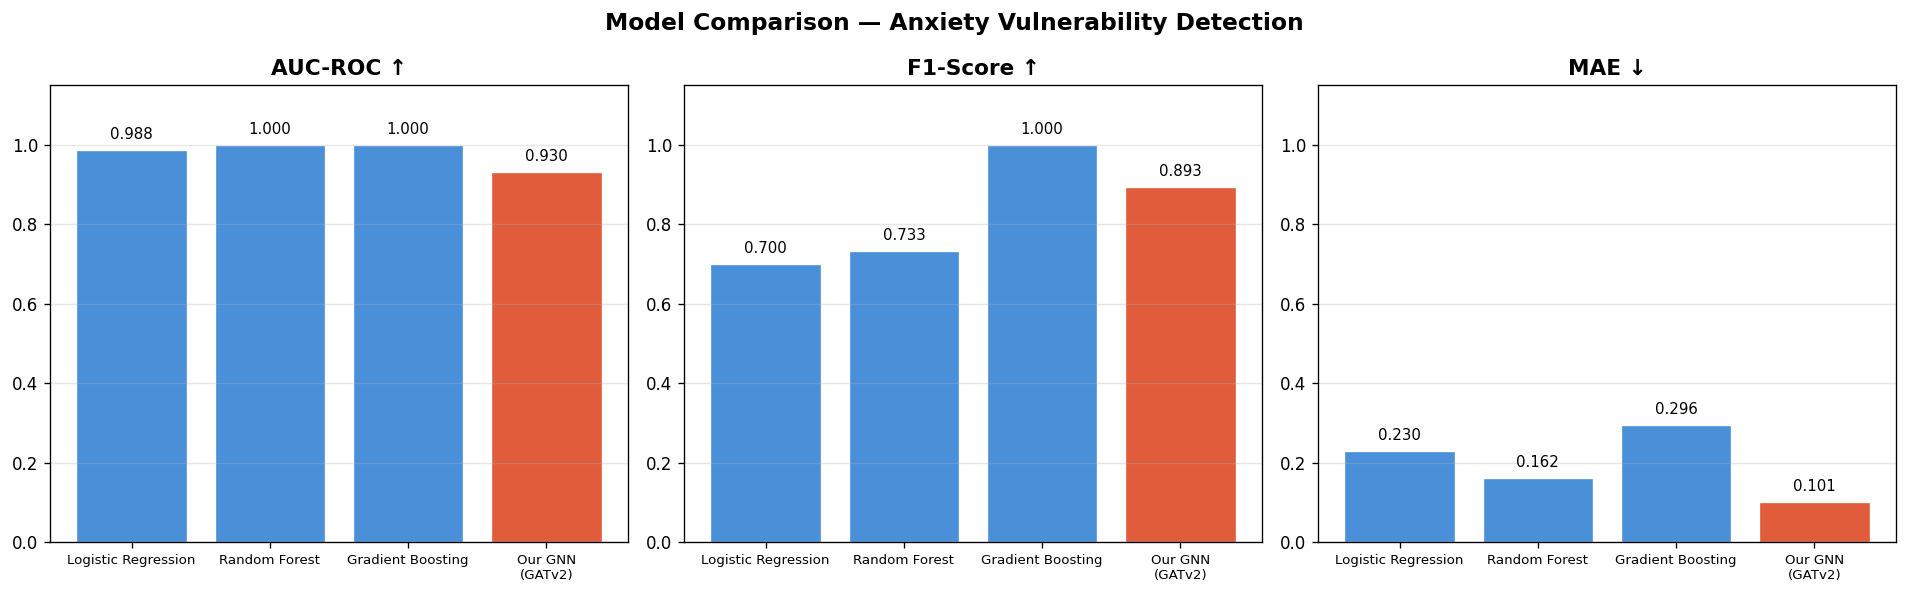

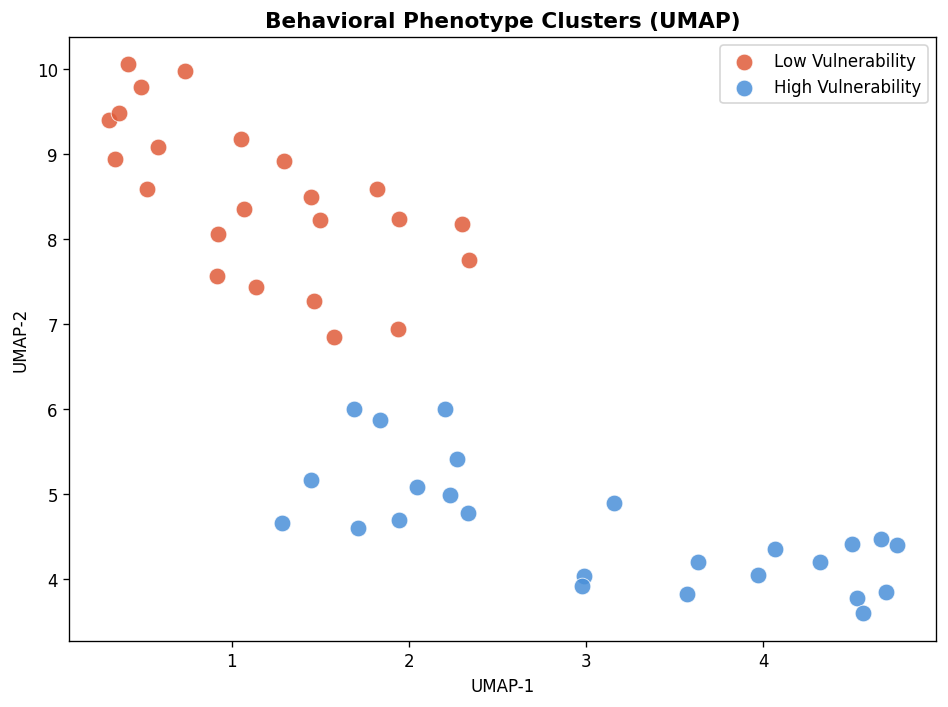

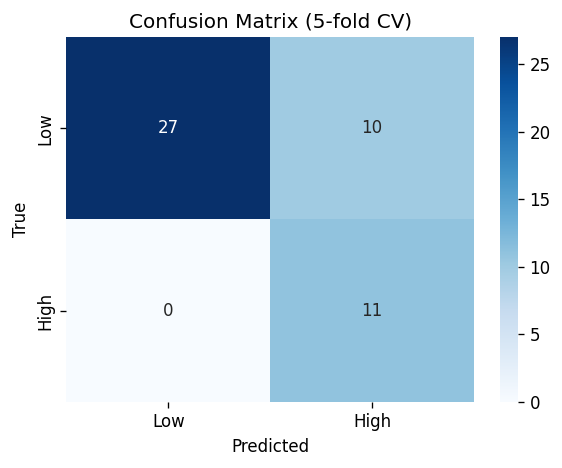


All plots saved to /content/drive/MyDrive/Anxiety/outputs/


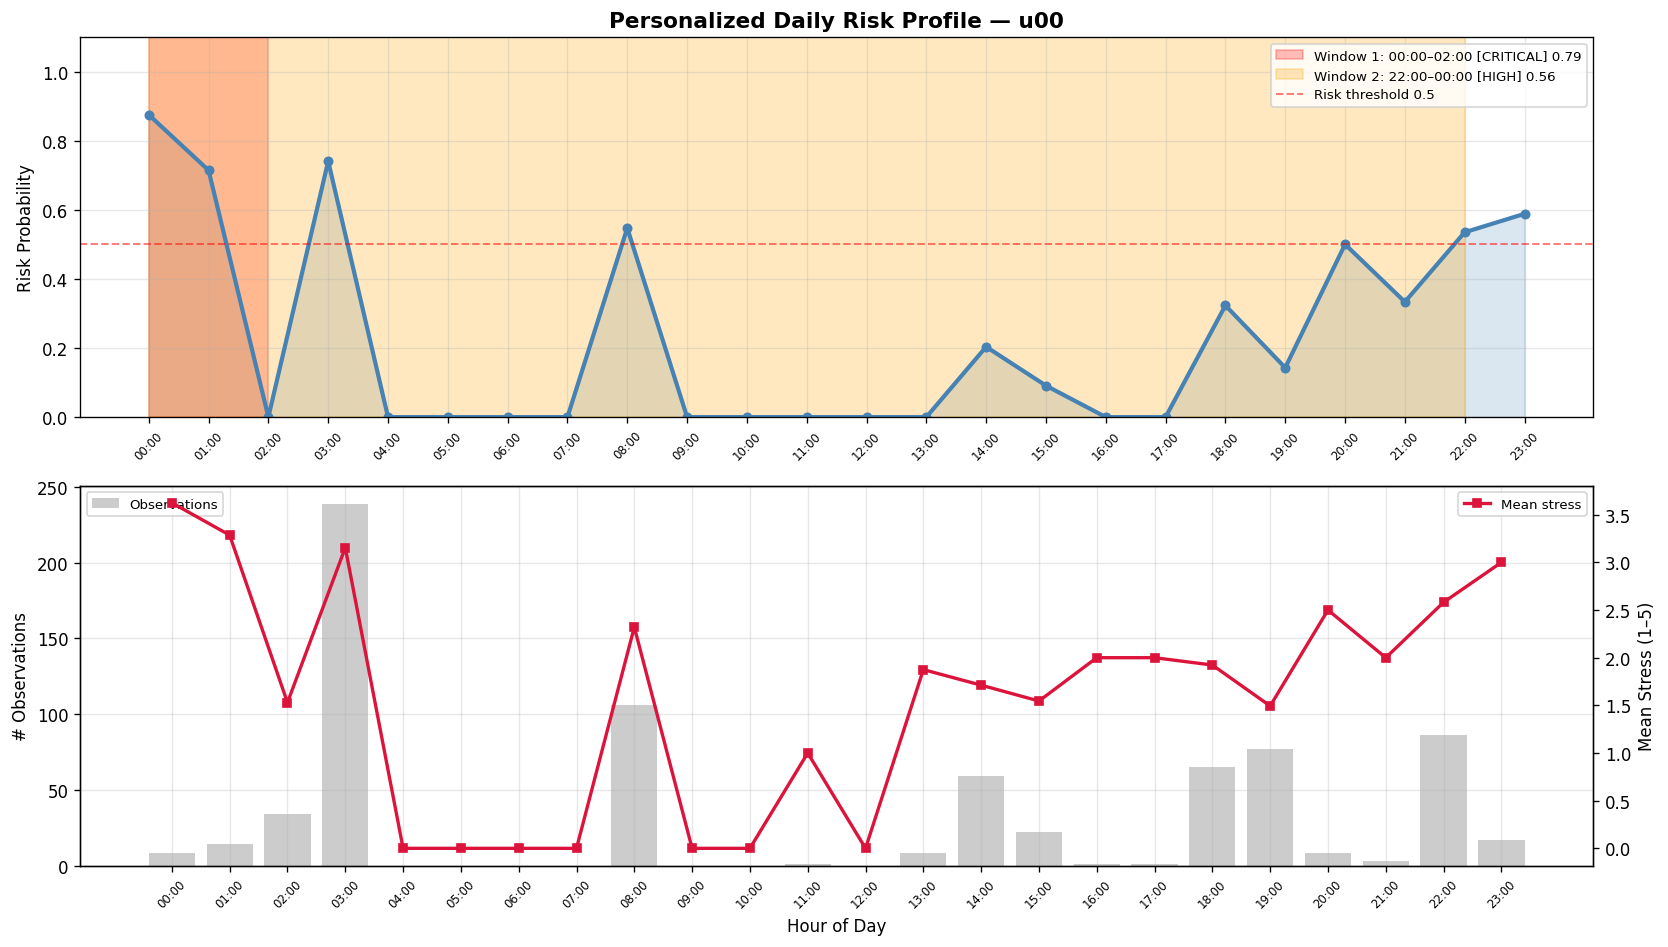

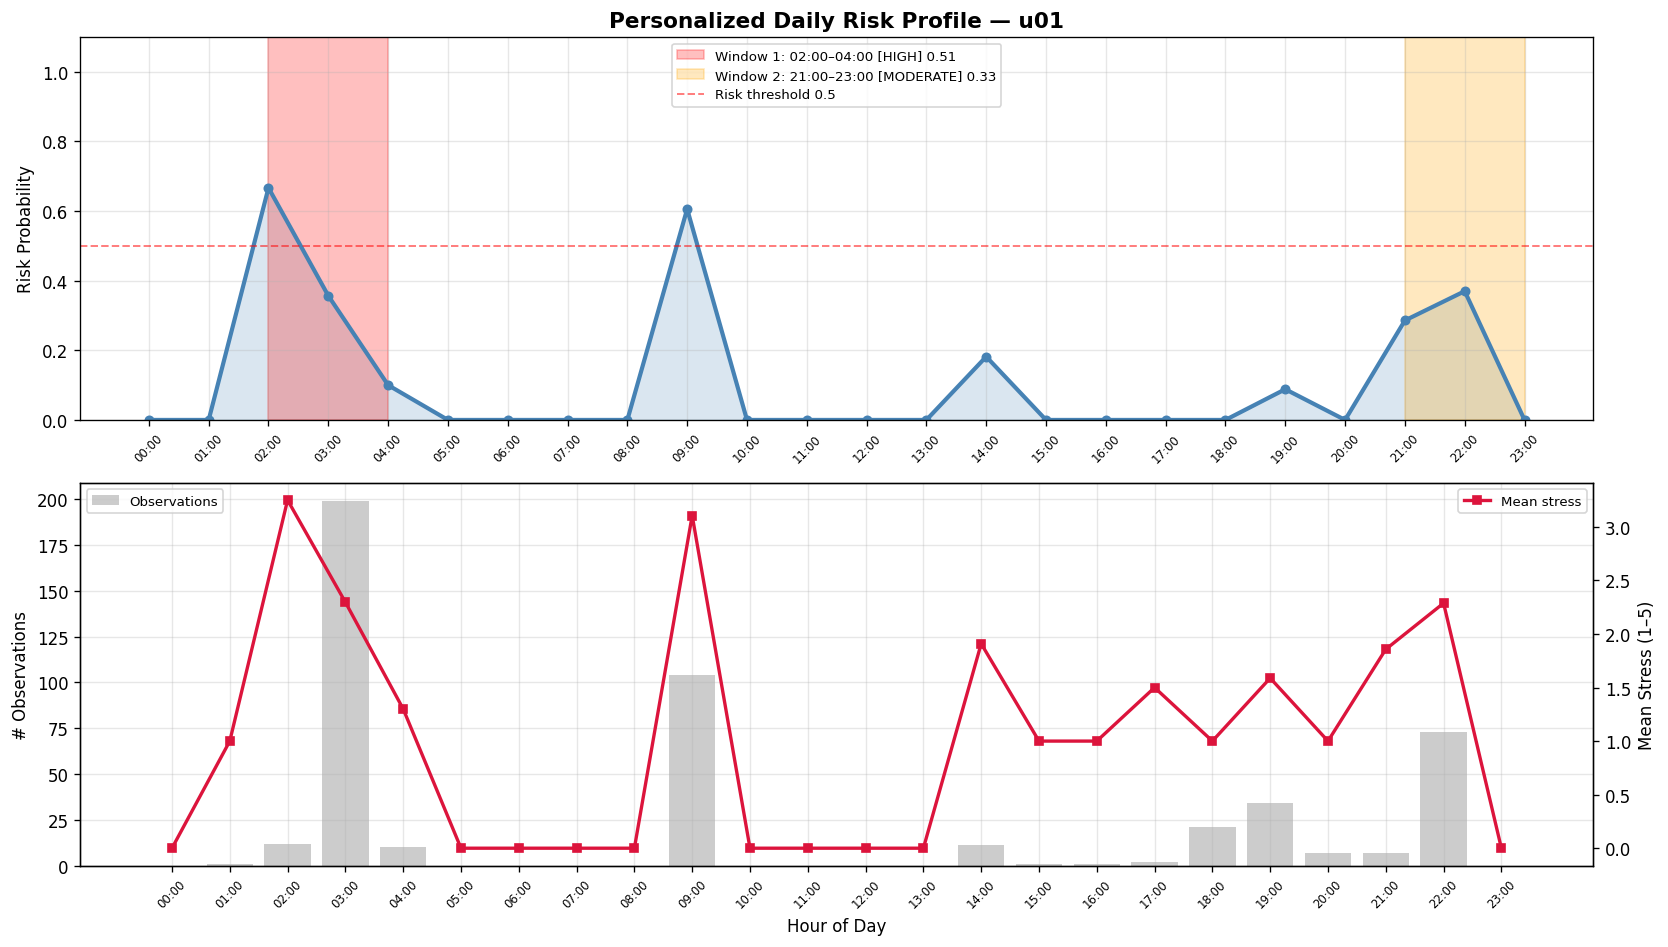

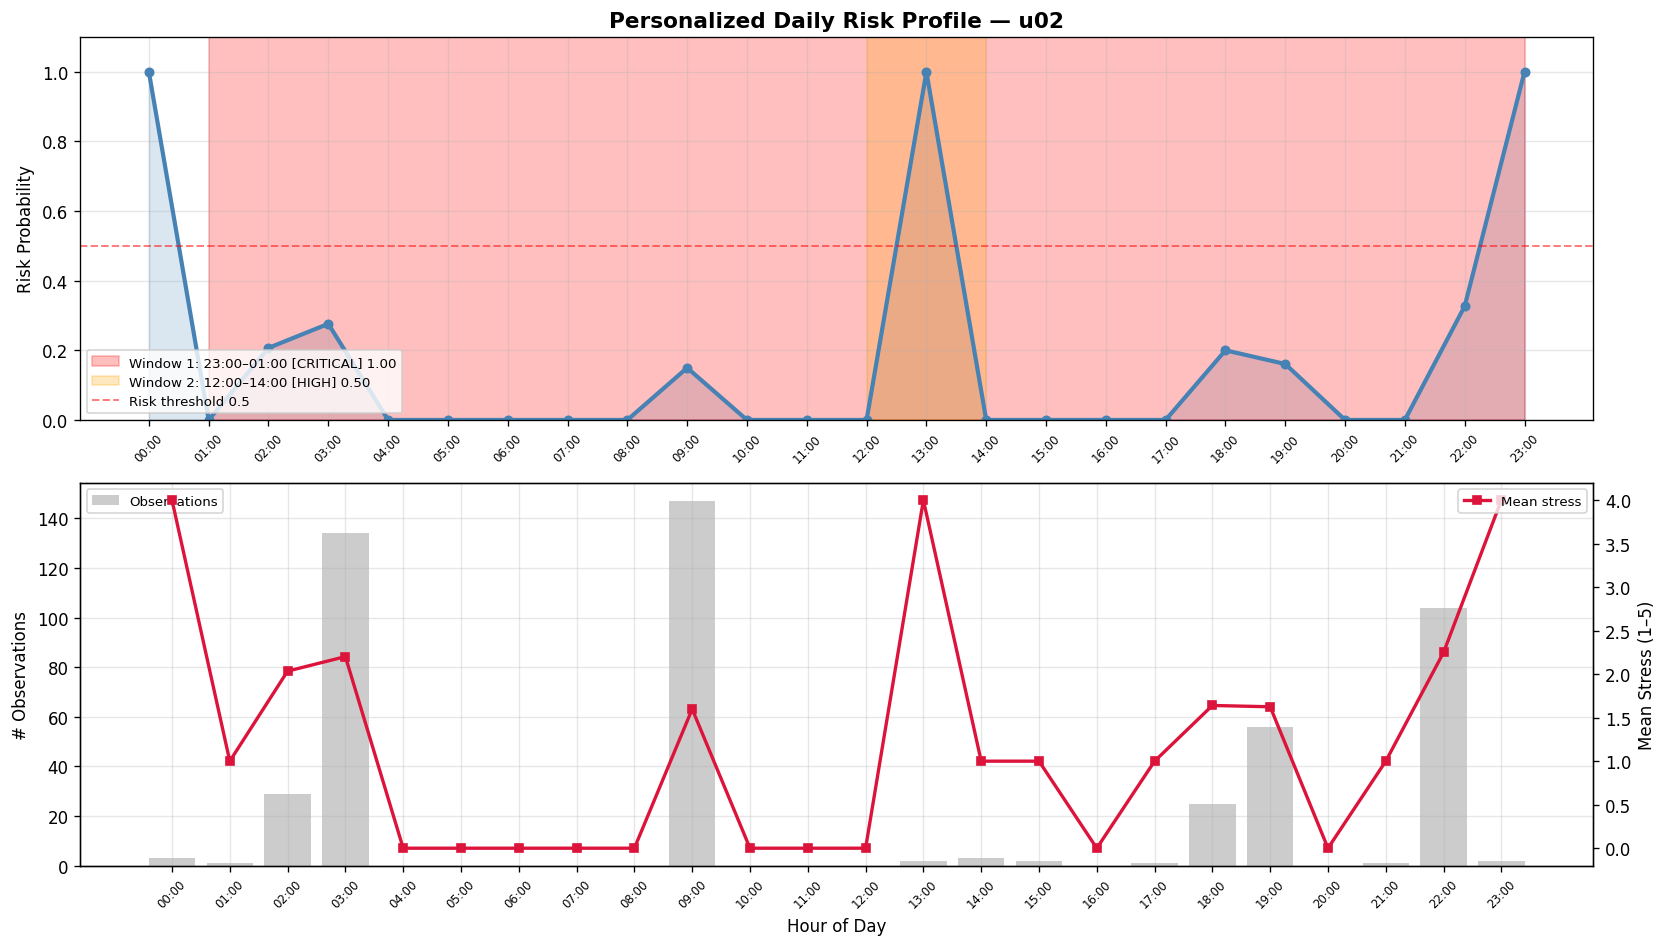

SAVE COMPLETE
Model    : /content/drive/MyDrive/Anxiety/models/gatv2_final_20260327_095022.pt
K-Means  : /content/drive/MyDrive/Anxiety/models/kmeans_20260327_095022.pkl
CV CSV   : /content/drive/MyDrive/Anxiety/outputs/cv_results_20260327_095022.csv
JSON     : /content/drive/MyDrive/Anxiety/outputs/vulnerability_output_20260327_095022.json
Meta     : /content/drive/MyDrive/Anxiety/models/pipeline_meta_20260327_095022.json

Sample output:
{
  "participant_id": "u00",
  "vulnerability_score": 0.4793,
  "risk_level": "MODERATE",
  "high_risk_window": "00:00",
  "phenotype_cluster": "High Vulnerability",
  "timestamp": "20260327_095022"
}
{
  "participant_id": "u00",
  "vulnerability_score": 0.5481,
  "risk_level": "HIGH",
  "high_risk_window": "afternoon",
  "phenotype_cluster": "High Vulnerability"
}


{'participant_id': 'u00',
 'vulnerability_score': 0.5481,
 'risk_level': 'HIGH',
 'high_risk_window': 'afternoon',
 'phenotype_cluster': 'High Vulnerability'}

In [ ]:
# ── CELL 14: Behavioral Phenotyping ─────────────────────────
# ============================================================

# Train final model on full dataset for embedding extraction
print("Training final model for phenotyping...")
full_loader   = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=False)
final_model   = AnxietyGATv2().to(device)
final_opt     = torch.optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-4)

for epoch in range(80):
    final_model.train()
    for batch in full_loader:
        batch = batch.to(device)
        final_opt.zero_grad()
        v, h = final_model(batch)
        compute_loss(v, h, batch, pos_weight).backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        final_opt.step()
    if epoch % 20 == 0:
        print(f"  epoch {epoch}")

# Extract embeddings
final_model.eval()
embeddings = []
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=4, shuffle=False):
        batch = batch.to(device)
        v, h  = final_model(batch)
        # Use the graph-level representation directly
        # We reconstruct it from the last pooling by re-running forward
        # but store it via a hook instead
        embeddings.append(v.squeeze(-1).cpu().numpy())  # placeholder — see below

# Better: extract embeddings via hook on xg
emb_list = []
def _hook(module, input, output):
    emb_list.append(output.detach().cpu())

# Attach hook to the vuln_head's first linear layer input
hook_handle = final_model.vuln_head[0].register_forward_hook(_hook)

final_model.eval()
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=4, shuffle=False):
        batch = batch.to(device)
        final_model(batch)

hook_handle.remove()
embeddings = torch.cat(emb_list, dim=0).numpy()
print(f"\nEmbeddings shape : {embeddings.shape}")

# K-Means phenotyping
best_k, best_sil = 3, -1
for k in [2, 3, 4]:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(embeddings)
    sil = silhouette_score(embeddings, lbl) if len(np.unique(lbl)) > 1 else -1
    print(f"  k={k}  silhouette={sil:.4f}")
    if sil > best_sil:
        best_sil, best_k = sil, k

km_final  = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters  = km_final.fit_predict(embeddings)
PHENOTYPES = {
    0: 'Social-Spatial Withdrawal',
    1: 'Circadian Disruption',
    2: 'Hypervigilant Mobility',
}
if best_k == 2:
    PHENOTYPES = {0: 'Low Vulnerability', 1: 'High Vulnerability'}
elif best_k == 4:
    PHENOTYPES[3] = 'Irregular Patterns'

print(f"\nBest k={best_k}  silhouette={best_sil:.4f}")
for c in range(best_k):
    print(f"  {PHENOTYPES.get(c, f'Cluster {c}'):30s}: {np.sum(clusters==c)} users")


# ── CELL 15: Plots ───────────────────────────────────────────
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Model comparison bar chart
models_list  = list(bl_results.keys()) + ['Our GNN\n(GATv2)']
auc_list     = [bl_results[m]['auc'] for m in bl_results] + [gnn_auc]
f1_list      = [bl_results[m]['f1']  for m in bl_results] + [gnn_f1]
mae_list     = [bl_results[m]['mae'] for m in bl_results] + [gnn_mae]
colors       = ['#4a90d9','#4a90d9','#4a90d9','#e05c3a']
x = np.arange(len(models_list))

for ax, vals, title in zip(axes,
        [auc_list, f1_list, mae_list],
        ['AUC-ROC ↑', 'F1-Score ↑', 'MAE ↓']):
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=8)
    ax.set_ylim(0, 1.15); ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Model Comparison — Anxiety Vulnerability Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "model_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

# 2. Phenotype UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb2d   = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#e05c3a','#4a90d9','#2ecc71','#9b59b6']
for c in range(best_k):
    mask = clusters == c
    ax.scatter(emb2d[mask,0], emb2d[mask,1],
               c=palette[c], label=PHENOTYPES.get(c, f'Cluster {c}'),
               s=100, alpha=0.85, edgecolors='white', linewidths=0.5)
ax.legend(fontsize=10)
ax.set_title('Behavioral Phenotype Clusters (UMAP)', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "phenotypes_umap.png", dpi=200, bbox_inches='tight')
plt.show()

# 3. Confusion matrix (all folds combined)
# Collect all fold predictions
all_true_combined, all_pred_combined = [], []
for fold, (tr_idx, te_idx) in enumerate(kf.split(dataset, y_labels)):
    tr_data = [dataset[i] for i in tr_idx]
    te_data = [dataset[i] for i in te_idx]
    _, preds, trues, _, _ = train_fold(tr_data, te_data, epochs=100)
    all_true_combined.extend((trues >= 0.5).astype(int))
    all_pred_combined.extend((preds >= 0.5).astype(int))

cm = confusion_matrix(all_true_combined, all_pred_combined)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low','High'], yticklabels=['Low','High'])
ax.set_title('Confusion Matrix (5-fold CV)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAll plots saved to {OUTPUT_DIR}")


# ── CELL 16: Per-User Risk Profile Plot (sample 3 users) ────
# ============================================================

def plot_risk_profile(uid, save=True):
    profile = all_profiles[uid]
    windows = all_windows[uid]
    hours   = list(range(24))
    risk_p  = [profile[h]['risk_probability'] for h in hours]
    mean_s  = [profile[h]['mean_stress']       for h in hours]
    obs_c   = [profile[h]['n_observations']    for h in hours]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    ax1.fill_between(hours, risk_p, alpha=0.2, color='steelblue')
    ax1.plot(hours, risk_p, 'o-', color='steelblue', linewidth=2.5, markersize=5)
    colors_w = ['red','orange']
    for i, w in enumerate(windows):
        lvl = risk_level(w['score'])
        ax1.axvspan(w['start'], w['end'], alpha=0.25, color=colors_w[i],
                    label=f"Window {i+1}: {w['start']:02d}:00–{w['end']:02d}:00 [{lvl}] {w['score']:.2f}")
    ax1.axhline(0.5, color='red', linestyle='--', alpha=0.5, linewidth=1.2, label='Risk threshold 0.5')
    ax1.set_title(f"Personalized Daily Risk Profile — {uid}", fontsize=13, fontweight='bold')
    ax1.set_ylabel('Risk Probability'); ax1.set_ylim(0, 1.1)
    ax1.set_xticks(hours)
    ax1.set_xticklabels([f"{h:02d}:00" for h in hours], rotation=45, fontsize=7)
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    ax2b = ax2.twinx()
    ax2.bar(hours, obs_c, alpha=0.4, color='gray', label='Observations')
    ax2b.plot(hours, mean_s, 's-', color='crimson', linewidth=2, markersize=5, label='Mean stress')
    ax2.set_ylabel('# Observations'); ax2b.set_ylabel('Mean Stress (1–5)')
    ax2.set_xlabel('Hour of Day')
    ax2.set_xticks(hours)
    ax2.set_xticklabels([f"{h:02d}:00" for h in hours], rotation=45, fontsize=7)
    ax2.legend(loc='upper left', fontsize=8)
    ax2b.legend(loc='upper right', fontsize=8)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR + f"risk_profile_{uid}.png", dpi=150, bbox_inches='tight')
    plt.show()

# Plot 3 sample users
sample_uids = sorted(user_graphs.keys())[:3]
for uid in sample_uids:
    plot_risk_profile(uid)


# ── CELL 17: Save Everything ─────────────────────────────────
# ============================================================

ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Final model weights
model_path = os.path.join(MODELS_DIR, f'gatv2_final_{ts}.pt')
torch.save({
    'model_state_dict': final_model.state_dict(),
    'model_config'    : {'node_feat':7,'hidden':64,'heads':4,'drop':0.3},
    'timestamp'       : ts,
}, model_path)

# K-Means
km_path = os.path.join(MODELS_DIR, f'kmeans_{ts}.pkl')
with open(km_path,'wb') as f:
    pickle.dump({'kmeans':km_final,'phenotypes':PHENOTYPES,
                 'silhouette':best_sil,'clusters':clusters.tolist(),
                 'uid_list':uid_list}, f)

# Embeddings
emb_path = os.path.join(MODELS_DIR, f'embeddings_{ts}.npy')
np.save(emb_path, embeddings)

# CV results CSV
cv_path = os.path.join(OUTPUT_DIR, f'cv_results_{ts}.csv')
cv_df.to_csv(cv_path, index=False)

# Per-user JSON output
output_json = []
for i, uid in enumerate(uid_list):
    g   = user_graphs[uid]
    all_sr = [s for n in g.nodes for s in g.nodes[n]['stress_readings']]
    vscore = float(np.mean([1 if s>=3 else 0 for s in all_sr])) if all_sr else 0.0
    ws  = all_windows.get(uid, [])
    hrw = f"{ws[0]['start']:02d}:00" if ws else 'unknown'
    output_json.append({
        'participant_id'   : uid,
        'vulnerability_score': round(vscore, 4),
        'risk_level'       : risk_level(vscore),
        'high_risk_window' : hrw,
        'phenotype_cluster': PHENOTYPES.get(int(clusters[i]), 'Unknown'),
        'timestamp'        : ts,
    })

json_path = os.path.join(OUTPUT_DIR, f'vulnerability_output_{ts}.json')
with open(json_path,'w') as f:
    json.dump(output_json, f, indent=2)

# Pipeline metadata
meta = {
    'timestamp'       : ts,
    'dataset'         : 'StudentLife',
    'n_participants'  : len(dataset),
    'label_type'      : label_type,
    'model'           : 'GATv2Conv + GlobalAttention',
    'cv_folds'        : 5,
    'performance'     : {
        'auc_mean' : round(float(valid_auc.mean()), 4),
        'auc_std'  : round(float(valid_auc.std()),  4),
        'f1_mean'  : round(float(cv_df['f1'].mean()),4),
        'mae_mean' : round(float(cv_df['mae'].mean()),4),
        'silhouette': round(float(best_sil), 4),
    },
    'phenotypes'      : PHENOTYPES,
    'files'           : {
        'model'     : model_path,
        'kmeans'    : km_path,
        'embeddings': emb_path,
        'cv_results': cv_path,
        'json_output': json_path,
    }
}
meta_path = os.path.join(MODELS_DIR, f'pipeline_meta_{ts}.json')
with open(meta_path,'w') as f:
    json.dump(meta, f, indent=2)

print("="*55)
print("SAVE COMPLETE")
print("="*55)
print(f"Model    : {model_path}")
print(f"K-Means  : {km_path}")
print(f"CV CSV   : {cv_path}")
print(f"JSON     : {json_path}")
print(f"Meta     : {meta_path}")
print(f"\nSample output:")
print(json.dumps(output_json[0], indent=2))


# ── CELL 18: Inference on a Single New User ──────────────────
# ============================================================

def predict_user(uid, model=None):
    """
    Run the full pipeline for a single user already in the dataset.
    Pass a trained model, or it uses final_model by default.
    """
    if model is None:
        model = final_model
    if uid not in user_graphs or uid not in all_profiles:
        print(f"User {uid} not found."); return None

    d     = graph_to_pyg(user_graphs[uid], uid, all_profiles[uid],
                         label_map.get(uid, 0.0))
    if d is None:
        print(f"Could not build graph for {uid}"); return None

    model.eval()
    with torch.no_grad():
        batch = Batch.from_data_list([d.to(device)])
        v, h  = model(batch)
        vscore = model.vulnerability_score(v)
        hrw    = model.high_risk_window()

    # Phenotype from K-Means
    i_in_list = uid_list.index(uid) if uid in uid_list else -1
    phenotype = PHENOTYPES.get(int(clusters[i_in_list]), 'Unknown') \
                if i_in_list >= 0 else 'Unknown'

    result = {
        'participant_id'    : uid,
        'vulnerability_score': round(vscore, 4),
        'risk_level'        : risk_level(vscore),
        'high_risk_window'  : hrw,
        'phenotype_cluster' : phenotype,
    }
    print(json.dumps(result, indent=2))
    return result

# Test on first user
predict_user(uid_list[0])

Running ablation study — this takes ~10 minutes...

Configuration                  AUC      F1     MAE
--------------------------------------------------
Full model (all 9)           0.923   0.671   0.098
Without stress               0.498   0.339   0.261
Without temporal             0.945   0.691   0.102
Without location             0.971   0.701   0.096
Without social               0.930   0.591   0.105


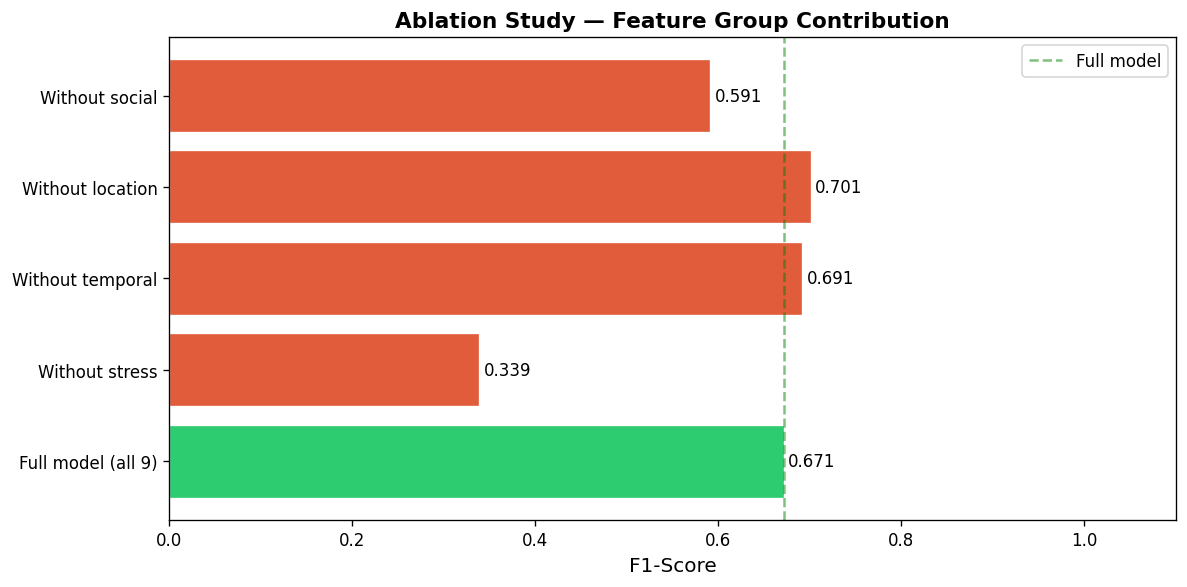


Ablation plot saved to /content/drive/MyDrive/Anxiety/outputs/


In [ ]:
# ── CELL 19: Ablation Study ──────────────────────────────────
# ============================================================

FEATURE_GROUPS = {
    'Full model (all 9)'      : list(range(9)),
    'Without stress'          : [0,1,2,3,7,8],      # remove idx 4,5,6
    'Without temporal'        : [0,3,4,5,6,7,8],    # remove idx 1,2
    'Without location'        : [1,2,4,5,6,7,8],    # remove idx 0,3
    'Without social'          : list(range(7)),      # remove idx 7,8
}

ablation_results = {}
print("Running ablation study — this takes ~10 minutes...\n")
print(f"{'Configuration':<26} {'AUC':>7} {'F1':>7} {'MAE':>7}")
print("-"*50)

for config_name, feat_idx in FEATURE_GROUPS.items():
    masked_dataset = []
    for d in dataset:
        d2   = d.clone()
        mask = torch.zeros(d.x.shape[1])
        mask[feat_idx] = 1.0
        d2.x = d.x * mask.unsqueeze(0)
        masked_dataset.append(d2.cpu())

    fold_auc, fold_f1, fold_mae = [], [], []
    for tr_idx, te_idx in kf.split(masked_dataset, y_labels):
        tr = [masked_dataset[i] for i in tr_idx]
        te = [masked_dataset[i] for i in te_idx]
        _, preds, trues, _, _ = train_fold(tr, te, epochs=150)
        bp = (preds >= 0.5).astype(int)
        bt = (trues >= 0.5).astype(int)
        fold_f1.append(f1_score(bt, bp, zero_division=0))
        fold_mae.append(mean_absolute_error(trues, preds))
        if len(np.unique(bt)) > 1:
            fold_auc.append(roc_auc_score(bt, preds))

    auc = np.mean(fold_auc) if fold_auc else float('nan')
    f1  = np.mean(fold_f1)
    mae = np.mean(fold_mae)
    ablation_results[config_name] = {'auc': auc, 'f1': f1, 'mae': mae}
    print(f"{config_name:<26} {auc:>7.3f} {f1:>7.3f} {mae:>7.3f}")

# Plot ablation
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(ablation_results.keys())
f1s    = [ablation_results[n]['f1'] for n in names]
colors = ['#2ecc71' if i == 0 else '#e05c3a' for i in range(len(names))]
bars   = ax.barh(names, f1s, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(f1s[0], color='green', linestyle='--', alpha=0.5, label='Full model')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Ablation Study — Feature Group Contribution',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, f1s):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.legend(fontsize=10)
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "ablation_study.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"\nAblation plot saved to {OUTPUT_DIR}")

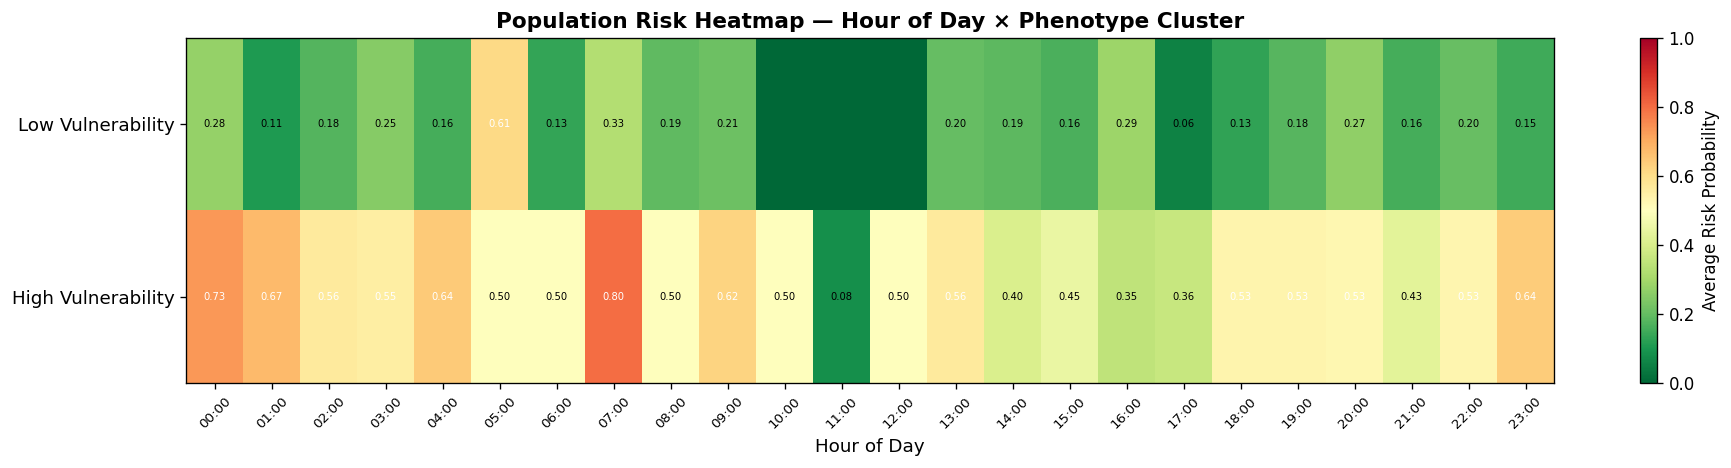

Heatmap saved to /content/drive/MyDrive/Anxiety/outputs/

Peak risk hours by phenotype:
---------------------------------------------
  Low Vulnerability             : 05:00  (risk=0.611)
  High Vulnerability            : 07:00  (risk=0.800)


In [ ]:
# ── CELL 20: Population Risk Heatmap ─────────────────────────
# ============================================================

n_clusters    = best_k
heatmap_data  = np.zeros((n_clusters, 24))
heatmap_count = np.zeros((n_clusters, 24))

for i, uid in enumerate(uid_list):
    c_id    = int(clusters[i])
    profile = all_profiles[uid]
    for h in range(24):
        if profile[h]['n_observations'] > 0:
            heatmap_data[c_id, h]  += profile[h]['risk_probability']
            heatmap_count[c_id, h] += 1

heatmap_avg = np.where(
    heatmap_count > 0,
    heatmap_data / heatmap_count,
    0
)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(heatmap_avg, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)],
                   rotation=45, fontsize=8)
ax.set_yticks(range(n_clusters))
ax.set_yticklabels([PHENOTYPES.get(c, f'Cluster {c}')
                    for c in range(n_clusters)], fontsize=11)
plt.colorbar(im, ax=ax, label='Average Risk Probability')
ax.set_title('Population Risk Heatmap — Hour of Day × Phenotype Cluster',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)

# Add value annotations inside cells
for ci in range(n_clusters):
    for h in range(24):
        val = heatmap_avg[ci, h]
        if val > 0:
            ax.text(h, ci, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=6,
                    color='white' if val > 0.5 else 'black')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "population_risk_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Heatmap saved to {OUTPUT_DIR}")

# Print summary table
print(f"\nPeak risk hours by phenotype:")
print("-"*45)
for c in range(n_clusters):
    peak_h = int(np.argmax(heatmap_avg[c]))
    peak_v = heatmap_avg[c, peak_h]
    name   = PHENOTYPES.get(c, f'Cluster {c}')
    print(f"  {name:<30}: {peak_h:02d}:00  (risk={peak_v:.3f})")